# 🧬 Pipeline de Splicing con CNN 1D - Google Colab Optimizado
## Configuración para Datasets Grandes (>100MB) en Google Drive

**Autores:** César Alexander Martínez Pérez | Guillermo Daniel Zaragoza Castro  
**Institución:** CUCEI, Universidad de Guadalajara  
**Fecha:** Mayo 2026

---

### Configuración Específica para Tu Caso:

| Parámetro | Valor |
|-----------|-------|
| **Ubicación de datos** | Google Drive (raíz) |
| **Tamaño de archivos** | > 100 MB |
| **Uso** | Múltiples ejecuciones |
| **Método de carga** | Google Drive Mount + Lazy Loading |

**Archivos requeridos en Google Drive:**
- `dataset_entrenamiento.csv` (raíz de Drive)
- `dataset_prueba.csv` (raíz de Drive)

---

### Tabla de Contenidos
1. [Configuración del Entorno](#config)
2. [Montar Google Drive](#drive)
3. [Verificar Archivos](#verificar)
4. [Cargar Datasets](#cargar)
5. [Arquitectura CNN](#arquitectura)
6. [Entrenamiento](#entrenamiento)
7. [Evaluación](#evaluacion)
8. [Interpretación del Modelo - Saliency Maps](#interpretacion)
9. [Extracción de Motivos PWM](#pwm)
10. [Aplicación a Genes de Interés](#genes)

<a id='config'></a>
## 1. Configuración del Entorno

---

## 0. Cargar Modelo Pre-entrenado (Opcional)

Si ya tienes un modelo entrenado en Google Drive, puedes cargarlo aquí para evitar re-entrenar.

```python
# Cargar modelo desde Drive
if DRIVE_ROOT and os.path.exists(os.path.join(DRIVE_ROOT, "modelo_splicing_best.pth")):
    checkpoint = torch.load(os.path.join(DRIVE_ROOT, "modelo_splicing_best.pth"), map_location="cpu")
    modelo.load_state_dict(checkpoint["model_state_dict"])
    print("✓ Modelo cargado desde Drive")
else:
    print("⚠ No hay modelo en Drive. Entrena uno nuevo.")
```


In [ ]:
# Verificar entorno
import sys
print(f"Python: {sys.version}")
print(f"Entorno: {'Google Colab' if 'google.colab' in sys.modules else 'Local'}")

# Instalar dependencias (solo Colab)
if 'google.colab' in sys.modules:
    !pip install -q torch torchvision torchaudio
    !pip install -q pandas numpy scikit-learn matplotlib seaborn
    print("✓ Dependencias instaladas")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Entorno: Google Colab
✓ Dependencias instaladas


In [ ]:
# Importaciones principales
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✓ Librerías importadas")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

# Verificar GPU
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

✓ Librerías importadas
PyTorch: 2.10.0+cpu
CUDA disponible: False


<a id='drive'></a>
## 2. Montar Google Drive

In [ ]:
from google.colab import drive

print("Montando Google Drive...")
drive.mount('/content/drive')
print("✓ Google Drive montado exitosamente")

Montando Google Drive...
Mounted at /content/drive
✓ Google Drive montado exitosamente


<a id='verificar'></a>
## 3. Verificar Archivos en Google Drive

In [ ]:
# Definir rutas a los archivos en Google Drive
DRIVE_ROOT = '/content/drive/MyDrive'

DATASET_ENTRENAMIENTO = os.path.join(DRIVE_ROOT, 'dataset_entrenamiento.csv')
DATASET_PRUEBA = os.path.join(DRIVE_ROOT, 'dataset_prueba.csv')

print("="*70)
print("VERIFICACIÓN DE ARCHIVOS EN GOOGLE DRIVE")
print("="*70)
print(f"\nRuta de entrenamiento: {DATASET_ENTRENAMIENTO}")
print(f"Ruta de prueba: {DATASET_PRUEBA}")
print()

# Verificar existencia
archivos_ok = True

if os.path.exists(DATASET_ENTRENAMIENTO):
    size = os.path.getsize(DATASET_ENTRENAMIENTO) / 1e6
    print(f"✓ dataset_entrenamiento.csv encontrado ({size:.2f} MB)")
else:
    print("✗ dataset_entrenamiento.csv NO encontrado")
    print("  → Sube el archivo a la raíz de tu Google Drive")
    archivos_ok = False

if os.path.exists(DATASET_PRUEBA):
    size = os.path.getsize(DATASET_PRUEBA) / 1e6
    print(f"✓ dataset_prueba.csv encontrado ({size:.2f} MB)")
else:
    print("✗ dataset_prueba.csv NO encontrado")
    print("  → Sube el archivo a la raíz de tu Google Drive")
    archivos_ok = False

print("\n" + "="*70)

if not archivos_ok:
    print("\n⚠ ERROR: Archivos no encontrados.")
    print("Por favor, sube los archivos a la raíz de Google Drive y reinicia el notebook.")
    print("\nPasos:")
    print("1. Abre https://drive.google.com")
    print("2. Sube 'dataset_entrenamiento.csv' y 'dataset_prueba.csv' a la raíz (MyDrive)")
    print("3. Reinicia el notebook (Runtime → Restart runtime)")
    print("4. Ejecuta todas las celdas nuevamente")

VERIFICACIÓN DE ARCHIVOS EN GOOGLE DRIVE

Ruta de entrenamiento: /content/drive/MyDrive/dataset_entrenamiento.csv
Ruta de prueba: /content/drive/MyDrive/dataset_prueba.csv

✓ dataset_entrenamiento.csv encontrado (160.11 MB)
✓ dataset_prueba.csv encontrado (40.03 MB)



In [ ]:
# Verificar estructura del Drive
print("Archivos en la raíz de tu Google Drive:")
!ls -lh /content/drive/MyDrive/*.csv 2>/dev/null || echo "No se encontraron archivos CSV en la raíz"

Archivos en la raíz de tu Google Drive:
-rw------- 1 root root 153M May 23 09:42 /content/drive/MyDrive/dataset_entrenamiento.csv
-rw------- 1 root root  39M May 23 09:42 /content/drive/MyDrive/dataset_prueba.csv


<a id='cargar'></a>
## 4. Cargar Datasets con Lazy Loading

In [ ]:
def codificar_one_hot(secuencia, max_length=200):
    """
    Codifica una secuencia de ADN a one-hot encoding.

    Mapeo:
    A -> [1, 0, 0, 0]
    C -> [0, 1, 0, 0]
    G -> [0, 0, 1, 0]
    T -> [0, 0, 0, 1]
    N -> [0, 0, 0, 0]  (nucleótido ambiguo)

    Args:
        secuencia: String de nucleótidos (ACGT)
        max_length: Longitud fija de salida (default: 200)

    Returns:
        torch.Tensor de forma (max_length, 4)
    """
    mapeo = {
        'A': [1, 0, 0, 0],
        'C': [0, 1, 0, 0],
        'G': [0, 0, 1, 0],
        'T': [0, 0, 0, 1],
        'N': [0, 0, 0, 0],
        'U': [0, 0, 0, 1],
    }

    # Inicializar matriz
    matriz = np.zeros((max_length, 4), dtype=np.float32)

    # Codificar cada nucleótido
    secuencia = secuencia.upper().strip()
    longitud = min(len(secuencia), max_length)

    for i, nucleotido in enumerate(secuencia[:longitud]):
        if nucleotido in mapeo:
            matriz[i] = mapeo[nucleotido]
        else:
            matriz[i] = [0, 0, 0, 0]  # Desconocido

    return torch.from_numpy(matriz)


class SplicingDatasetLazy(Dataset):
    """
    Dataset con carga diferida (lazy loading) para manejar datasets ILIMITADOS.

    Ventajas:
    - Memoria constante: solo carga 1 muestra a la vez
    - Escala a millones de muestras sin OOM (Out Of Memory)
    - Codificación one-hot bajo demanda
    - Compatible con Google Drive

    Desventaja:
    - Ligeramente más lento por codificación repetida
    """

    def __init__(self, csv_path, max_length=200):
        """
        Inicializa el dataset con carga diferida.

        Args:
            csv_path: Ruta al archivo CSV (local o Google Drive)
            max_length: Longitud máxima de secuencias (default: 200)
        """
        self.csv_path = csv_path
        self.max_length = max_length

        print(f"[LazyDataset] Cargando índices desde {csv_path}...")

        # Solo cargar columnas necesarias (menor uso de memoria)
        self.df = pd.read_csv(csv_path, usecols=['sequence', 'label'])

        print(f"✓ Dataset cargado: {len(self.df):,} muestras")
        print(f"  - Memoria usada: ~{self.df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
        print(f"  - Clase 0: {(self.df['label']==0).sum():,}")
        print(f"  - Clase 1: {(self.df['label']==1).sum():,}")

    def __len__(self):
        """Retorna el total de elementos en el dataset."""
        return len(self.df)

    def __getitem__(self, idx):
        """
        Obtiene una muestra individual con codificación bajo demanda.

        Args:
            idx: Índice de la muestra

        Returns:
            tensor_secuencia: torch.Tensor (200, 4) one-hot encoded
            etiqueta: torch.Tensor (1,) float
        """
        # Obtener secuencia y label
        row = self.df.iloc[idx]
        secuencia = row['sequence']
        etiqueta = row['label']

        # Codificación one-hot (al vuelo)
        tensor_secuencia = codificar_one_hot(secuencia, self.max_length)
        tensor_etiqueta = torch.tensor(etiqueta, dtype=torch.float32)

        return tensor_secuencia, tensor_etiqueta

In [ ]:
# Cargar datasets desde Google Drive
print("\n" + "="*70)
print("CARGA DE DATASETS DESDE GOOGLE DRIVE")
print("="*70)

# Crear datasets
train_dataset = SplicingDatasetLazy(DATASET_ENTRENAMIENTO)
test_dataset = SplicingDatasetLazy(DATASET_PRUEBA)

print(f"\n✓ Datasets cargados exitosamente")
print(f"  - Entrenamiento: {len(train_dataset):,} muestras")
print(f"  - Prueba: {len(test_dataset):,} muestras")


CARGA DE DATASETS DESDE GOOGLE DRIVE
[LazyDataset] Cargando índices desde /content/drive/MyDrive/dataset_entrenamiento.csv...
✓ Dataset cargado: 725,724 muestras
  - Memoria usada: ~186.51 MB
  - Clase 0: 362,862
  - Clase 1: 362,862
[LazyDataset] Cargando índices desde /content/drive/MyDrive/dataset_prueba.csv...
✓ Dataset cargado: 181,432 muestras
  - Memoria usada: ~46.63 MB
  - Clase 0: 90,716
  - Clase 1: 90,716

✓ Datasets cargados exitosamente
  - Entrenamiento: 725,724 muestras
  - Prueba: 181,432 muestras


In [ ]:
# Crear DataLoaders
def crear_dataloaders(train_dataset, test_dataset, batch_size=32):
    """
    Crea DataLoaders para entrenamiento y prueba.

    Args:
        train_dataset: Dataset de entrenamiento
        test_dataset: Dataset de prueba
        batch_size: Tamaño de batch (recomendado: 32-64 para GPU)

    Returns:
        train_loader, test_loader
    """
    # Dividir entrenamiento en train/validación (80/20)
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size

    train_subset, val_subset = torch.utils.data.random_split(
        train_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    # Crear loaders
    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,  # Aumentar si hay memoria
        pin_memory=True  # Acelera transferencia a GPU
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader


# Configurar batch size según GPU
if torch.cuda.is_available():
    GPU_MEMORY = torch.cuda.get_device_properties(0).total_memory / 1e9
    if GPU_MEMORY > 10:
        BATCH_SIZE = 64
    elif GPU_MEMORY > 6:
        BATCH_SIZE = 32
    else:
        BATCH_SIZE = 16
else:
    BATCH_SIZE = 16  # CPU: batch más pequeño

print(f"Batch size automático: {BATCH_SIZE}")

# Crear loaders
train_loader, val_loader, test_loader = crear_dataloaders(
    train_dataset,
    test_dataset,
    batch_size=BATCH_SIZE
)

print(f"\n✓ DataLoaders creados:")
print(f"  - Train: {len(train_loader)} batches")
print(f"  - Val: {len(val_loader)} batches")
print(f"  - Test: {len(test_loader)} batches")

Batch size automático: 16

✓ DataLoaders creados:
  - Train: 36287 batches
  - Val: 9072 batches
  - Test: 11340 batches


<a id='arquitectura'></a>
## 5. Arquitectura CNN 1D

In [ ]:
class SplicingCNN1D(nn.Module):
    """
    Red Neuronal Convolucional 1D para clasificación de sitios de splicing.

    Arquitectura:
    - 3 bloques convolucionales con kernels decrecientes (15, 11, 9)
    - Batch Normalization para estabilidad
    - Dropout para regularización
    - MaxPooling para reducción dimensional
    - 2 capas fully connected para clasificación
    """

    def __init__(
        self,
        input_length=200,
        input_channels=4,
        filtros=[64, 128, 256],
        kernels=[15, 11, 9],
        dropout_conv=0.4,
        dropout_fc=0.5
    ):
        super(SplicingCNN1D, self).__init__()

        # BLOQUE 1: Motivos largos (kernel=15)
        self.conv1 = nn.Conv1d(input_channels, filtros[0], kernel_size=kernels[0], padding=kernels[0]//2)
        self.bn1 = nn.BatchNorm1d(filtros[0])
        self.dropout1 = nn.Dropout(dropout_conv)
        self.pool1 = nn.MaxPool1d(kernel_size=4, stride=4)

        # BLOQUE 2: Motivos medios (kernel=11)
        self.conv2 = nn.Conv1d(filtros[0], filtros[1], kernel_size=kernels[1], padding=kernels[1]//2)
        self.bn2 = nn.BatchNorm1d(filtros[1])
        self.dropout2 = nn.Dropout(dropout_conv)
        self.pool2 = nn.MaxPool1d(kernel_size=4, stride=4)

        # BLOQUE 3: Motivos cortos (kernel=9)
        self.conv3 = nn.Conv1d(filtros[1], filtros[2], kernel_size=kernels[2], padding=kernels[2]//2)
        self.bn3 = nn.BatchNorm1d(filtros[2])
        self.dropout3 = nn.Dropout(dropout_conv - 0.1)
        self.pool3 = nn.MaxPool1d(kernel_size=3, stride=3)

        # Cálculo de features después de pooling
        # 200 -> 50 -> 12 -> 4
        features_size = filtros[2] * 4

        # CAPAS DENSAS
        self.fc1 = nn.Linear(features_size, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.dropout_fc = nn.Dropout(dropout_fc)
        self.fc2 = nn.Linear(256, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch, 200, 4)
        # Permutar a (batch, 4, 200) para Conv1D
        x = x.permute(0, 2, 1)

        # Bloque 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(self.dropout1(x))

        # Bloque 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(self.dropout2(x))

        # Bloque 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(self.dropout3(x))

        # Flatten + FC
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.sigmoid(self.fc2(self.dropout_fc(x)))

        return x


def contar_parametros(modelo):
    """Cuenta parámetros totales y entrenables."""
    total = sum(p.numel() for p in modelo.parameters())
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    return total, entrenables


# Crear modelo
modelo = SplicingCNN1D()
total, train = contar_parametros(modelo)

print("="*70)
print("ARQUITECTURA CNN 1D")
print("="*70)
print(f"\nParámetros totales: {total:,}")
print(f"Parámetros entrenables: {train:,}")
print(f"\nEntrada: (batch, 200, 4)")
print(f"Salida: (batch, 1)")
print("\nArquitectura:")
print(modelo)

ARQUITECTURA CNN 1D

Parámetros totales: 653,377
Parámetros entrenables: 653,377

Entrada: (batch, 200, 4)
Salida: (batch, 1)

Arquitectura:
SplicingCNN1D(
  (conv1): Conv1d(4, 64, kernel_size=(15,), stride=(1,), padding=(7,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.4, inplace=False)
  (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 128, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.4, inplace=False)
  (pool2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(128, 256, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.30000000000000004, inplace=False)
  (pool3): MaxPool1d(kernel_size=3, st

<a id='entrenamiento'></a>
## 6. Entrenamiento del Modelo

In [ ]:
def entrenar_epoch(modelo, loader, criterion, optimizer, device):
    """Entrena un epoch completo."""
    modelo.train()
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0

    for batch_idx, (sequences, labels) in enumerate(loader):
        sequences = sequences.to(device)
        labels = labels.to(device)

        # Gradientes a cero
        optimizer.zero_grad()

        # Forward pass
        outputs = modelo(sequences).squeeze()

        # Calcular pérdida
        loss = criterion(outputs, labels.float())

        # Backward pass
        loss.backward()
        optimizer.step()

        # Acumular métricas
        total_loss += loss.item()
        predictions = (outputs >= 0.5).float()
        correct = (predictions == labels.float()).sum().item()
        total_acc += correct
        num_batches += 1

    avg_loss = total_loss / num_batches
    avg_acc = total_acc / len(loader.dataset) * 100

    return avg_loss, avg_acc


def validar_epoch(modelo, loader, criterion, device):
    """Valida un epoch completo."""
    modelo.eval()
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0

    with torch.no_grad():
        for sequences, labels in loader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = modelo(sequences).squeeze()

            # Calcular pérdida
            loss = criterion(outputs, labels.float())

            # Acumular métricas
            total_loss += loss.item()
            predictions = (outputs >= 0.5).float()
            correct = (predictions == labels.float()).sum().item()
            total_acc += correct
            num_batches += 1

    avg_loss = total_loss / num_batches
    avg_acc = total_acc / len(loader.dataset) * 100

    return avg_loss, avg_acc


def entrenar_modelo(
    modelo,
    train_loader,
    val_loader,
    num_epochs=50,
    lr=0.001,
    device='cpu',
    save_path=None
):
    """
    Entrena el modelo con early stopping implícito.

    Args:
        modelo: Red neuronal PyTorch
        train_loader: DataLoader de entrenamiento
        val_loader: DataLoader de validación
        num_epochs: Número de épocas
        lr: Learning rate
        device: 'cuda' o 'cpu'
        save_path: Ruta para guardar el mejor modelo (Google Drive)

    Returns:
        modelo: Modelo entrenado
        historial: Diccionario con métricas por época
    """
    print("="*70)
    print("ENTRENAMIENTO DEL MODELO CNN 1D")
    print("="*70)
    print(f"Dispositivo: {device}")
    if device == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Épocas: {num_epochs}")
    print(f"Learning rate: {lr}")
    print("="*70)

    # Mover modelo a dispositivo
    modelo = modelo.to(device)

    # Configurar pérdida y optimizador
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-5)

    # Historial
    historial = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    # Mejor modelo
    best_val_loss = float('inf')
    best_model_state = None

    # Entrenamiento
    for epoch in range(1, num_epochs + 1):
        # Train
        train_loss, train_acc = entrenar_epoch(modelo, train_loader, criterion, optimizer, device)

        # Validate
        val_loss, val_acc = validar_epoch(modelo, val_loader, criterion, device)

        # Guardar métricas
        historial['train_loss'].append(train_loss)
        historial['val_loss'].append(val_loss)
        historial['train_acc'].append(train_acc)
        historial['val_acc'].append(val_acc)

        # Guardar mejor modelo
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in modelo.state_dict().items()}

        # Imprimir progreso (cada 5 épocas o primera/última)
        if epoch % 5 == 0 or epoch == 1 or epoch == num_epochs:
            print(f"Época {epoch:3d}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Cargar mejor modelo
    if best_model_state is not None:
        modelo.load_state_dict(best_model_state)

    print("="*70)
    print(f"[OK] Entrenamiento completado.")
    print(f"Mejor Val Loss: {best_val_loss:.4f}")

    # Guardar modelo si se especificó ruta
    if save_path:
        torch.save({
            'epoch': num_epochs,
            'model_state_dict': modelo.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'historial': historial
        }, save_path)
        print(f"\n✓ Modelo guardado: {save_path}")

    return modelo, historial

In [ ]:
# Configurar dispositivo
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Ruta para guardar modelo en Google Drive
SAVE_MODEL_PATH = '/content/drive/MyDrive/modelo_splicing_best.pth'

# Entrenar modelo
modelo_entrenado, historial = entrenar_modelo(
    modelo=modelo,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=50,
    lr=0.001,
    device=DEVICE,
    save_path=SAVE_MODEL_PATH
)

# Extraer mejor Val Loss del checkpoint guardado
checkpoint = torch.load(SAVE_MODEL_PATH, map_location='cpu', weights_only=False)
best_val_loss = checkpoint['best_val_loss']

ENTRENAMIENTO DEL MODELO CNN 1D
Dispositivo: cuda
GPU: Tesla T4
Épocas: 50
Learning rate: 0.001
Época   1/50 | Train Loss: 0.2353 | Train Acc: 90.66% | Val Loss: 0.1814 | Val Acc: 93.82%
Época   5/50 | Train Loss: 0.1502 | Train Acc: 94.67% | Val Loss: 0.1525 | Val Acc: 94.71%
Época  10/50 | Train Loss: 0.1431 | Train Acc: 94.95% | Val Loss: 0.1801 | Val Acc: 93.47%
Época  15/50 | Train Loss: 0.1409 | Train Acc: 94.99% | Val Loss: 0.1822 | Val Acc: 93.42%
Época  20/50 | Train Loss: 0.1389 | Train Acc: 95.08% | Val Loss: 0.1612 | Val Acc: 94.40%
Época  25/50 | Train Loss: 0.1383 | Train Acc: 95.10% | Val Loss: 0.2007 | Val Acc: 92.30%
Época  30/50 | Train Loss: 0.1384 | Train Acc: 95.09% | Val Loss: 0.1578 | Val Acc: 94.83%
Época  35/50 | Train Loss: 0.1373 | Train Acc: 95.12% | Val Loss: 0.1960 | Val Acc: 92.89%
Época  40/50 | Train Loss: 0.1371 | Train Acc: 95.15% | Val Loss: 0.1728 | Val Acc: 94.01%
Época  45/50 | Train Loss: 0.1372 | Train Acc: 95.17% | Val Loss: 0.1848 | Val Acc: 9

In [ ]:
# Cargar checkpoint
checkpoint = torch.load('/content/drive/MyDrive/modelo_splicing_best.pth', map_location='cpu', weights_only=False)

# Extraer historial
historial = checkpoint['historial']

# Convertir a DataFrame
df = pd.DataFrame(historial)

# Usar métricas
print(df.describe())
print(f"Train Loss final: {df['train_loss'].iloc[-1]:.4f}")
print(f"Val Accuracy final: {df['val_acc'].iloc[-1]:.2f}%")

# Guardar para análisis posterior
df.to_csv('metricas_entrenamiento.csv', index=False)

       train_loss   val_loss  train_acc    val_acc
count   50.000000  50.000000  50.000000  50.000000
mean     0.142535   0.180233  94.928477  93.464494
std      0.014616   0.019578   0.655339   1.046931
min      0.136587   0.145333  90.664492  89.569741
25%      0.137231   0.166893  94.975791  92.855248
50%      0.138395   0.178590  95.095586  93.566434
75%      0.141280   0.194090  95.145536  94.204761
max      0.235312   0.245333  95.190491  95.157946
Train Loss final: 0.1367
Val Accuracy final: 92.64%


In [ ]:
# Datos disponibles en el checkpoint
epoch_final = checkpoint['epoch']              # Número de épocas
best_val_loss = checkpoint['best_val_loss']    # Mejor validación
historial = checkpoint['historial']            # Diccionario con todo el historial

# Acceder a métricas específicas
train_loss = historial['train_loss']           # Lista con train_loss por época
val_loss = historial['val_loss']               # Lista con val_loss por época
train_acc = historial['train_acc']             # Lista con train_acc por época
val_acc = historial['val_acc']                 # Lista con val_acc por época

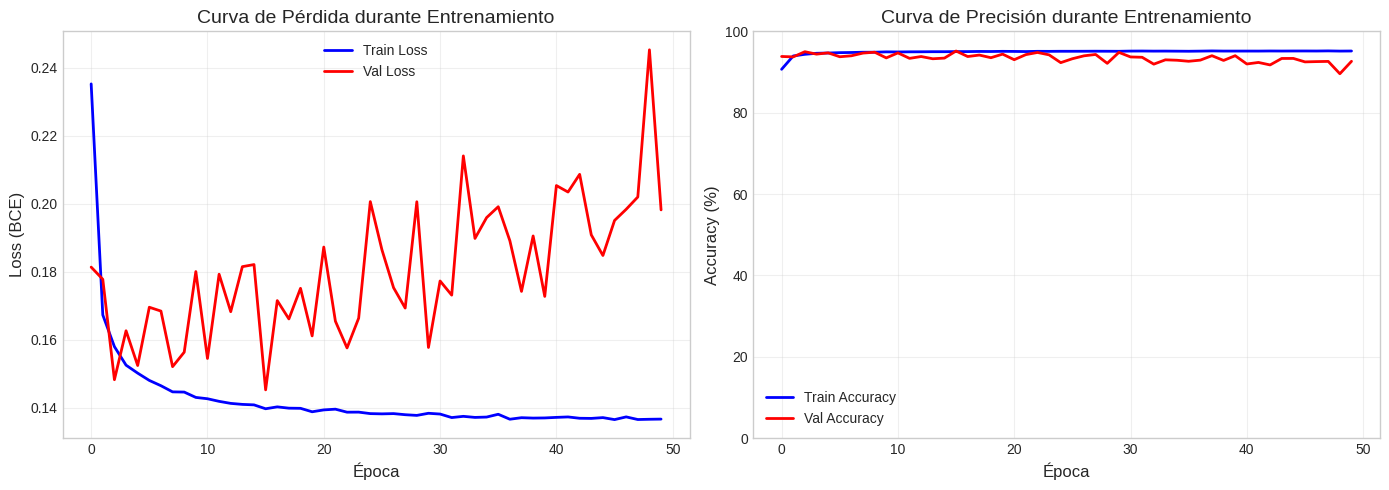

✓ Gráficas guardadas en Google Drive


In [ ]:
# Plotear curvas de entrenamiento
def plotear_curvas(historial):
    """Genera gráficas de loss y accuracy."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(historial['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(historial['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Época', fontsize=12)
    ax1.set_ylabel('Loss (BCE)', fontsize=12)
    ax1.set_title('Curva de Pérdida durante Entrenamiento', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(historial['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
    ax2.plot(historial['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
    ax2.set_xlabel('Época', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title('Curva de Precisión durante Entrenamiento', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 100])

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/curvas_entrenamiento.png', dpi=150)
    plt.show()
    print("✓ Gráficas guardadas en Google Drive")


# Generar gráficas
plotear_curvas(historial)

<a id='evaluacion'></a>
## 7. Evaluación en Dataset de Prueba

In [ ]:
def evaluar_modelo(modelo, loader, device='cpu'):
    """
    Evalúa modelo y regresa predicciones y labels.

    Args:
        modelo: Modelo entrenado
        loader: DataLoader
        device: 'cuda' o 'cpu'

    Returns:
        predicciones: Probabilidades de clase positiva
        labels: Etiquetas reales
    """
    modelo.eval()
    modelo.to(device)

    predicciones = []
    labels = []

    with torch.no_grad():
        for sequences, labels_batch in loader:
            sequences = sequences.to(device)
            outputs = modelo(sequences).squeeze()

            predicciones.extend(outputs.cpu().numpy())
            labels.extend(labels_batch.numpy())

    return np.array(predicciones), np.array(labels)


# Evaluar en test set
print("\n" + "="*70)
print("EVALUACIÓN EN DATASET DE PRUEBA")
print("="*70)

predicciones, labels_reales = evaluar_modelo(modelo_entrenado, test_loader, DEVICE)

print(f"\n✓ Evaluación completada: {len(predicciones):,} muestras")


EVALUACIÓN EN DATASET DE PRUEBA


NameError: name 'modelo_entrenado' is not defined

In [ ]:
# Métricas completas
def mostrar_metricas(predicciones, labels_reales, threshold=0.5):
    """Muestra todas las métricas de evaluación."""
    from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

    # Predicciones binarias
    predicciones_binarias = (predicciones >= threshold).astype(int)

    print("\n" + "="*70)
    print("MÉTRICAS DE EVALUACIÓN")
    print("="*70)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(labels_reales, predicciones_binarias,
                                target_names=['Clase 0 (Señuelo)', 'Clase 1 (Verdadero)'],
                                digits=4))

    # Matriz de confusión
    cm = confusion_matrix(labels_reales, predicciones_binarias)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Real 0', 'Real 1'])
    plt.title('Matriz de Confusión', fontsize=14)
    plt.ylabel('Etiqueta Real', fontsize=12)
    plt.xlabel('Etiqueta Predicha', fontsize=12)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/matriz_confusion.png', dpi=150)
    plt.show()

    # Curva ROC
    fpr, tpr, _ = roc_curve(labels_reales, predicciones)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Curva ROC', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/curva_roc.png', dpi=150)
    plt.show()

    print(f"\nAUC-ROC: {roc_auc:.4f}")
    print("="*70)

    return roc_auc


# Mostrar métricas
roc_auc = mostrar_metricas(predicciones, labels_reales)

NameError: name 'predicciones' is not defined

In [ ]:
# Resumen final
print("\n" + "="*70)
print("RESUMEN DEL PROYECTO")
print("="*70)

print("\n📊 DATASETS:")
print(f"  - Entrenamiento: {len(train_dataset):,} muestras")
print(f"  - Validación: {len(val_loader.dataset):,} muestras")
print(f"  - Prueba: {len(test_dataset):,} muestras")

print("\n🏗️  ARQUITECTURA:")
print(f"  - Modelo: SplicingCNN1D")
print(f"  - Parámetros: {total:,}")

print("\n🎯 RESULTADOS:")
print(f"  - Mejor Val Loss: {best_val_loss:.4f}")
print(f"  - Val Accuracy final: {historial['val_acc'][-1]:.2f}%")
print(f"  - Test AUC-ROC: {roc_auc:.4f}")

print("\n💾 ARCHIVOS GUARDADOS EN GOOGLE DRIVE:")
print(f"  - Modelo: {SAVE_MODEL_PATH}")
print(f"  - Curvas: /content/drive/MyDrive/curvas_entrenamiento.png")
print(f"  - Matriz: /content/drive/MyDrive/matriz_confusion.png")
print(f"  - ROC: /content/drive/MyDrive/curva_roc.png")

print("\n" + "="*70)
print("✅ PIPELINE COMPLETADO EXITOSAMENTE")
print("="*70)


RESUMEN DEL PROYECTO

📊 DATASETS:
  - Entrenamiento: 725,724 muestras
  - Validación: 145,145 muestras
  - Prueba: 181,432 muestras

🏗️  ARQUITECTURA:
  - Modelo: SplicingCNN1D
  - Parámetros: 653,377

🎯 RESULTADOS:
  - Mejor Val Loss: 0.1453
  - Val Accuracy final: 92.64%


NameError: name 'roc_auc' is not defined

---
## 📝 Notas Importantes

### Cargar modelo entrenado previamente:
```python
# Cargar checkpoint
checkpoint = torch.load('/content/drive/MyDrive/modelo_splicing_best.pth')
modelo_entrenado.load_state_dict(checkpoint['model_state_dict'])
```

### Ajustar hiperparámetros:
Modifica los valores en la celda de entrenamiento:
- `num_epochs=50` → Número de épocas
- `lr=0.001` → Learning rate
- `BATCH_SIZE=32` → Tamaño de batch

---
**Fin del Notebook**